In [2]:
#Ethiopia and Somalia
import pandas as pd
df = pd.read_csv("../../data/raw/wfp/wfp_food_prices_eastern_africa_2019-2025_10countries_118487records.csv")
eth = df[df['countryiso3']=='ETH']

In [3]:
target_df = df[df['countryiso3'].isin(['KEN', 'ETH', 'SOM'])]
target_df['commodity'].contans(Sorghum)

AttributeError: 'Series' object has no attribute 'contans'

In [61]:
eth = df[df['countryiso3']=='ETH']
sorghum_eth = eth[eth['commodity'].str.contains('Sorghum', case=False)]
sorghum_eth['unit_denomination'] = sorghum_eth['unit'].str.extract(r'(\d+)')[0]
sorghum_eth['unit_denomination'] = pd.to_numeric(sorghum_eth['unit_denomination'], errors='coerce').fillna(1).astype(int)

# Calculate per unit price
sorghum_eth['per_unit_price'] = sorghum_eth['usdprice'] / sorghum_eth['unit_denomination']
sorghum_eth.head()



/var/folders/t7/ldqv1xt97rs4jyjvhxf4shgw0000gn/T/ipykernel_5683/4156883326.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/t7/ldqv1xt97rs4jyjvhxf4shgw0000gn/T/ipykernel_5683/4156883326.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/t7/ldqv1xt97rs4jyjvhxf4shgw0000gn/T/ipykernel_5683/4156883326.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,unit_denomination,per_unit_price
225,ETH,2019-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Sorghum (red),282,100 KG,actual,Wholesale,ETB,822.60,29.11,100,0.2911
227,ETH,2019-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Sorghum (white),135,100 KG,actual,Wholesale,ETB,1511.17,53.47,100,0.5347
1443,ETH,2019-02-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Sorghum (white),135,100 KG,actual,Wholesale,ETB,1511.40,53.11,100,0.5311
2465,ETH,2019-03-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Sorghum (red),282,100 KG,actual,Wholesale,ETB,772.50,27.29,100,0.2729
2466,ETH,2019-03-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Sorghum (white),135,100 KG,actual,Wholesale,ETB,1498.17,52.92,100,0.5292


# 1. SPI visualization

In [2]:
import pandas as pd
spi  =pd.read_csv('../data/processed/spi/06_spi_csv/east_africa_spi_gamma_3_month.csv') 
spi_with_boundaries = pd.read_csv('../data/processed/spi/06_spi_csv/east_africa_spi_gamma_3_month_with_boundaries.csv')


/var/folders/t7/ldqv1xt97rs4jyjvhxf4shgw0000gn/T/ipykernel_5683/1463723998.py:3: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  spi_with_boundaries = pd.read_csv('../data/processed/spi/06_spi_csv/east_africa_spi_gamma_3_month_with_boundaries.csv')


In [41]:
# spi[spi['country_iso']=='ETH']
len(spi)

163036800

In [4]:
spi.head()

,Unnamed: 0,lat,lon,time,spi_gamma_3_month
0,0,-14.975002,25.024994,1991-01-01,NaN
1,1,-14.975002,25.024994,1991-02-01,NaN
2,2,-14.975002,25.024994,1991-03-01,-0.016625
3,3,-14.975002,25.024994,1991-04-01,-0.501111
4,4,-14.975002,25.024994,1991-05-01,-0.895417


In [42]:
spi_with_boundaries = pd.read_csv('../data/processed/spi/06_spi_csv/east_africa_spi_gamma_3_month_with_boundaries.csv')
eth_spi = spi_with_boundaries[spi_with_boundaries['country_iso']=='ETH']
recent_eth_spi = eth_spi[eth_spi['time']>'2015-01-01']

/var/folders/t7/ldqv1xt97rs4jyjvhxf4shgw0000gn/T/ipykernel_5683/2106448059.py:1: DtypeWarning:

Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.



<Axes: xlabel='time'>

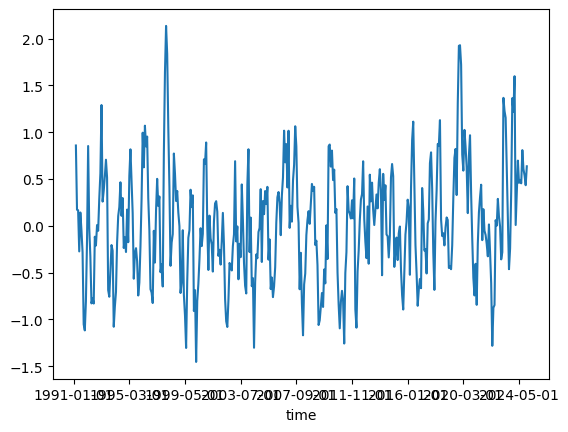

In [43]:
eth_spi.groupby('time')['spi_gamma_3_month'].mean().plot()


In [9]:
recent_eth_spi.head()

,Unnamed: 0,lat,lon,time,spi_gamma_3_month,country_iso,admin1,admin2,admin3
81196369,81196369,3.424999,39.524994,2015-02-01,-0.736124,ETH,Somali,Liben,Moyale
81196370,81196370,3.424999,39.524994,2015-03-01,0.470423,ETH,Somali,Liben,Moyale
81196371,81196371,3.424999,39.524994,2015-04-01,0.555980,ETH,Somali,Liben,Moyale
81196372,81196372,3.424999,39.524994,2015-05-01,0.422528,ETH,Somali,Liben,Moyale
81196373,81196373,3.424999,39.524994,2015-06-01,0.286956,ETH,Somali,Liben,Moyale


In [44]:
import pandas as pd
import plotly.express as px

def generate_map(recent_eth_spi):

        
    # 시간 정렬 및 문자열 변환
    recent_eth_spi['time'] = pd.to_datetime(recent_eth_spi['time'])
    recent_eth_spi = recent_eth_spi.sort_values('time')
    recent_eth_spi['time_str'] = recent_eth_spi['time'].dt.strftime('%Y-%m-%d')
    
    # NaN 제거
    plot_df = recent_eth_spi.dropna(subset=['spi_gamma_3_month'])
    
    if plot_df.empty:
        print("No valid data points to plot.")
        return None

    # 시각화
    fig = px.scatter_mapbox(
        plot_df,
        lat="lat",
        lon="lon",
        color="spi_gamma_3_month",
        animation_frame="time_str",
        color_continuous_scale="RdBu", 
        range_color=[-3, 3],
        zoom=5,
        center={"lat": 9.145, "lon": 40.489673},
        height=800,
        title="SPI (Standardized Precipitation Index) - Ethiopia",
        opacity=0.7,
        mapbox_style="carto-positron"
    )
    fig.update_traces(marker=dict(size=5))
    fig.show()

# 사용 예시 (노트북에서)
# dataset = pd.read_csv('../data/processed/spi/06_spi_csv/east_africa_spi_gamma_3_month_with_boundaries.csv', chunksize=1_000_000)
# generate_map(dataset)



In [45]:

tmp = recent_eth_spi[recent_eth_spi['time']=='2015-02-01']
generate_map(tmp)

/var/folders/t7/ldqv1xt97rs4jyjvhxf4shgw0000gn/T/ipykernel_5683/1210451056.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/t7/ldqv1xt97rs4jyjvhxf4shgw0000gn/T/ipykernel_5683/1210451056.py:20: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [46]:
import matplotlib.pyplot as plt
import plotly.express as px

df = (recent_eth_spi
      .groupby(['time', 'admin3'], as_index=False)
      .agg(spi_gamma_3_month=('spi_gamma_3_month', 'mean'))
     )

fig = px.line(
    df,
    x="time",
    y="spi_gamma_3_month",
    color="admin3",          # 라인 구분
    markers=True,            # 옵션: 점 표시
    title="SPI gamma (3-month) over time by admin3"
)

# time이 문자열이면 날짜로 변환(필요할 때만)
# df["time"] = pd.to_datetime(df["time"])

fig.update_layout(
    xaxis_title="time",
    yaxis_title="spi_gamma_3_month",
    legend_title="admin3",
    hovermode="x unified"
)

fig.show()

## 1-2. Can we find the drought using SPI data?

In [47]:

fig = px.histogram(
    df,
    x="spi_gamma_3_month",
    animation_frame="time",
    nbins=40,
    title="Distribution over time (animated)"
)
fig.show()

In [48]:
import plotly.express as px
import plotly.graph_objects as go

fig = px.violin(
    df,
    x="time",
    y="spi_gamma_3_month",
    points=False,
    box=False,
    title="Distribution by time (with mean dots)"
)

mean_df = df.groupby("time", as_index=False)["spi_gamma_3_month"].mean()

fig.add_trace(
    go.Scatter(
        x=mean_df["time"],
        y=mean_df["spi_gamma_3_month"],
        mode="markers",
        marker=dict(size=7),
        name="Mean"
    )
)

fig.update_layout(hovermode="x unified")
fig.show()

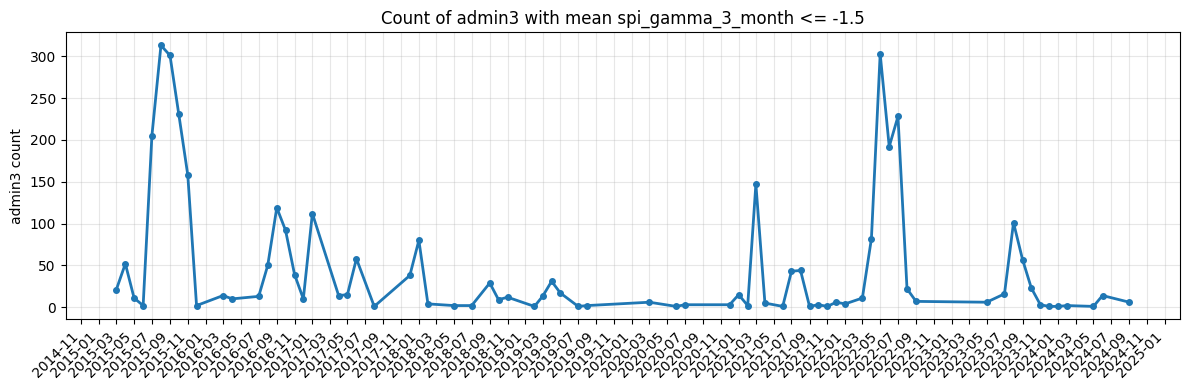

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# time 정리(문자열이면 datetime으로) + 정렬
cnt_df = cnt_df.copy()
cnt_df["time"] = pd.to_datetime(cnt_df["time"], errors="coerce")
cnt_df = cnt_df.sort_values("time")

ax = cnt_df.plot(
    x="time",
    y="n_admin3_leq_threshold",
    figsize=(12, 4),
    lw=2,
    marker="o",
    ms=4,
    legend=False
)

ax.set_title("Count of admin3 with mean spi_gamma_3_month <= -1.5")
ax.set_xlabel("")
ax.set_ylabel("admin3 count")
ax.grid(True, alpha=0.3)

# x축 날짜 라벨 깔끔하게 (월 단위 예시)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # 2개월마다(필요하면 1/3/6으로)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 1-3. How does the prices look like?

In [72]:
eth
eth['unit'] = eth['unit'].replace("KG", "1 KG").replace('L', '1L')
eth['unit'].unique()

eth['unit_denomination'] = eth['unit'].str.extract(r'(\d+)')[0]
eth['unit_denomination'] = eth['unit_denomination'].astype(float)
eth['unit_denomination'].unique()
eth['price_per_unit(usd)'] = eth['usdprice']/eth['unit_denomination']
eth['price_per_unit(usd)'].unique()

eth = eth.dropna()

# df = (recent_eth_spi
#       .groupby(['time', 'admin3'], as_index=False)
#       .agg(spi_gamma_3_month=('spi_gamma_3_month', 'mean'))
#      )

# fig = px.line(
#     df,
#     x="time",
#     y="spi_gamma_3_month",
#     color="admin3",          # 라인 구분
#     markers=True,            # 옵션: 점 표시
#     title="SPI gamma (3-month) over time by admin3"
# )
eth.head()

/var/folders/t7/ldqv1xt97rs4jyjvhxf4shgw0000gn/T/ipykernel_5683/1332488876.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/t7/ldqv1xt97rs4jyjvhxf4shgw0000gn/T/ipykernel_5683/1332488876.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/t7/ldqv1xt97rs4jyjvhxf4shgw0000gn/T/ipykernel_5683/1332488876.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,unit_denomination,price_per_unit(usd)
208,ETH,2019-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Maize (white),67,100 KG,actual,Wholesale,ETB,674.25,23.86,100.0,0.2386
225,ETH,2019-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Sorghum (red),282,100 KG,actual,Wholesale,ETB,822.60,29.11,100.0,0.2911
227,ETH,2019-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Sorghum (white),135,100 KG,actual,Wholesale,ETB,1511.17,53.47,100.0,0.5347
228,ETH,2019-01-15,Amhara,E. GOJAM,Debre Markos,502,10.33,37.73,cereals and tubers,Wheat,84,100 KG,actual,Wholesale,ETB,1265.00,44.76,100.0,0.4476
243,ETH,2019-01-15,Oromia,E. SHEWA,Shashemene,488,7.18,38.58,cereals and tubers,Wheat,84,100 KG,actual,Wholesale,ETB,1400.00,49.54,100.0,0.4954


In [89]:

# df = (eth
#       .groupby(['time'], as_index=False)
#       .agg(spi_gamma_3_month=('spi_gamma_3_month', 'mean'))
#      )

eth_month = eth.groupby(['date','commodity'], as_index=False).agg(average_price = ('price_per_unit(usd)', 'mean'))
eth_month
fig = px.line(
    eth_month,
    x="date",
    y="average_price",
    color="commodity",          # 라인 구분
    markers=True,            # 옵션: 점 표시
    title="Average price of food per commodity in Ethiopiaover time by commodity"
)
fig.show()

- Obviously in 2022 ~ 2022, sudden price increase mostly driven by sorghum (mixed)

In [111]:
base_price = (
    eth_month
    .groupby("commodity", as_index=False)
    .agg(base_price=("average_price", "mean"))
)

eth_inf = eth_month.merge(base_price, on="commodity", how="left")

eth_inf["inflation_vs_base"] = (
    (eth_inf["average_price"] / eth_inf["base_price"] - 1) * 100
)

fig = px.line(
    eth_inf,
    x="date",
    y="inflation_yoy",
    facet_col="commodity",
    facet_col_wrap=4,           # 한 줄에 4개씩
    facet_col_spacing=0.03,
    facet_row_spacing=0.05,
    title="YoY Inflation by Commodity (Small Multiples)"
)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))  # facet 제목 깔끔하게
fig.update_yaxes(matches=None)  # y축 스케일 공유 안 하고 각자
fig.add_hline(y=0, line_dash="dash")
fig.update_yaxes(nticks=3)   # y축 눈금 3개 정도로 제한
fig.update_yaxes(tickfont=dict(size=8))  # 숫자 글자 크기 줄이기
# labels로 이름을 사람이 읽기 좋게 바꿔주고
fig = px.line(
    eth_inf,
    x="date",
    y="inflation_yoy",
    facet_col="commodity",
    facet_col_wrap=4,
    facet_col_spacing=0.03,
    facet_row_spacing=0.05,
    title="YoY Inflation by Commodity (Small Multiples)",
    labels={"inflation_yoy": "YoY inflation (%)"}
)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

# 일단 전부 y축 제목 제거
fig.update_yaxes(title_text="")

# 첫 번째 y축(왼쪽 맨 위)만 다시 제목 넣기
fig.layout.yaxis.title = "YoY inflation (%)"
fig.update_xaxes(showticklabels=True)
fig.update_layout(
    width=1200,   # 가로 크게
    height=900,   # 세로도 크게
    margin=dict(l=60, r=30, t=60, b=60)
)
fig.update_xaxes(showticklabels=True)
fig.show()

In [118]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# 수준(label) 구분 컬럼 만들기
# 2) 단계 구분 함수: 110 / 130 기준
def classify_level(x):
    if x >= 130:
        return ">= 130"
    elif x >= 110:
        return "110–130"
    else:
        return "< 110"

eth_inf["level"] = eth_inf["inflation_yoy"].apply(classify_level)

# 1) 기본 선: 회색으로 commodity별 facet
fig = px.line(
    eth_inf,
    x="date",
    y="inflation_yoy",
    facet_col="commodity",
    facet_col_wrap=4,
    facet_col_spacing=0.03,
    facet_row_spacing=0.05,
    title="YoY Inflation by Commodity (Threshold Highlight)",
    # labels={"inflation_yoy": "YoY inflation (%)"}
)

# 2) 위에 색깔 점을 덧씌움: level 별 색깔
fig2 = px.scatter(
    eth_inf,
    x="date",
    y="inflation_yoy",
    facet_col="commodity",
    facet_col_wrap=4,
    facet_col_spacing=0.03,
    facet_row_spacing=0.05,
    color="level",
    # labels={"inflation_yoy": "YoY inflation (%)", "level": "Level"},
)

# scatter trace만 가져와서 fig에 추가
for tr in fig2.data:
    fig.add_trace(tr)

# 120, 140 기준선
fig.add_hline(y=120, line_dash="dash", line_color="orange")
fig.add_hline(y=140, line_dash="dash", line_color="red")

fig.update_yaxes(matches=None, nticks=3, tickfont=dict(size=8))
# fig.layout.yaxis.title = "YoY inflation (%)"
fig.update_layout(
    width=1600,
    height=900,
    margin=dict(l=60, r=30, t=60, b=60)
)
fig.update_xaxes(showticklabels=True)
fig.show()

## 1-4. Is the food price increase in 2022 due to the drought? How can you prove?

- Controlling factors:
- 

## 1-5. If there impact is because of the drought, how long does it take for the food price to increase?

# Data sparsity problem

Sorghum records found: 1573


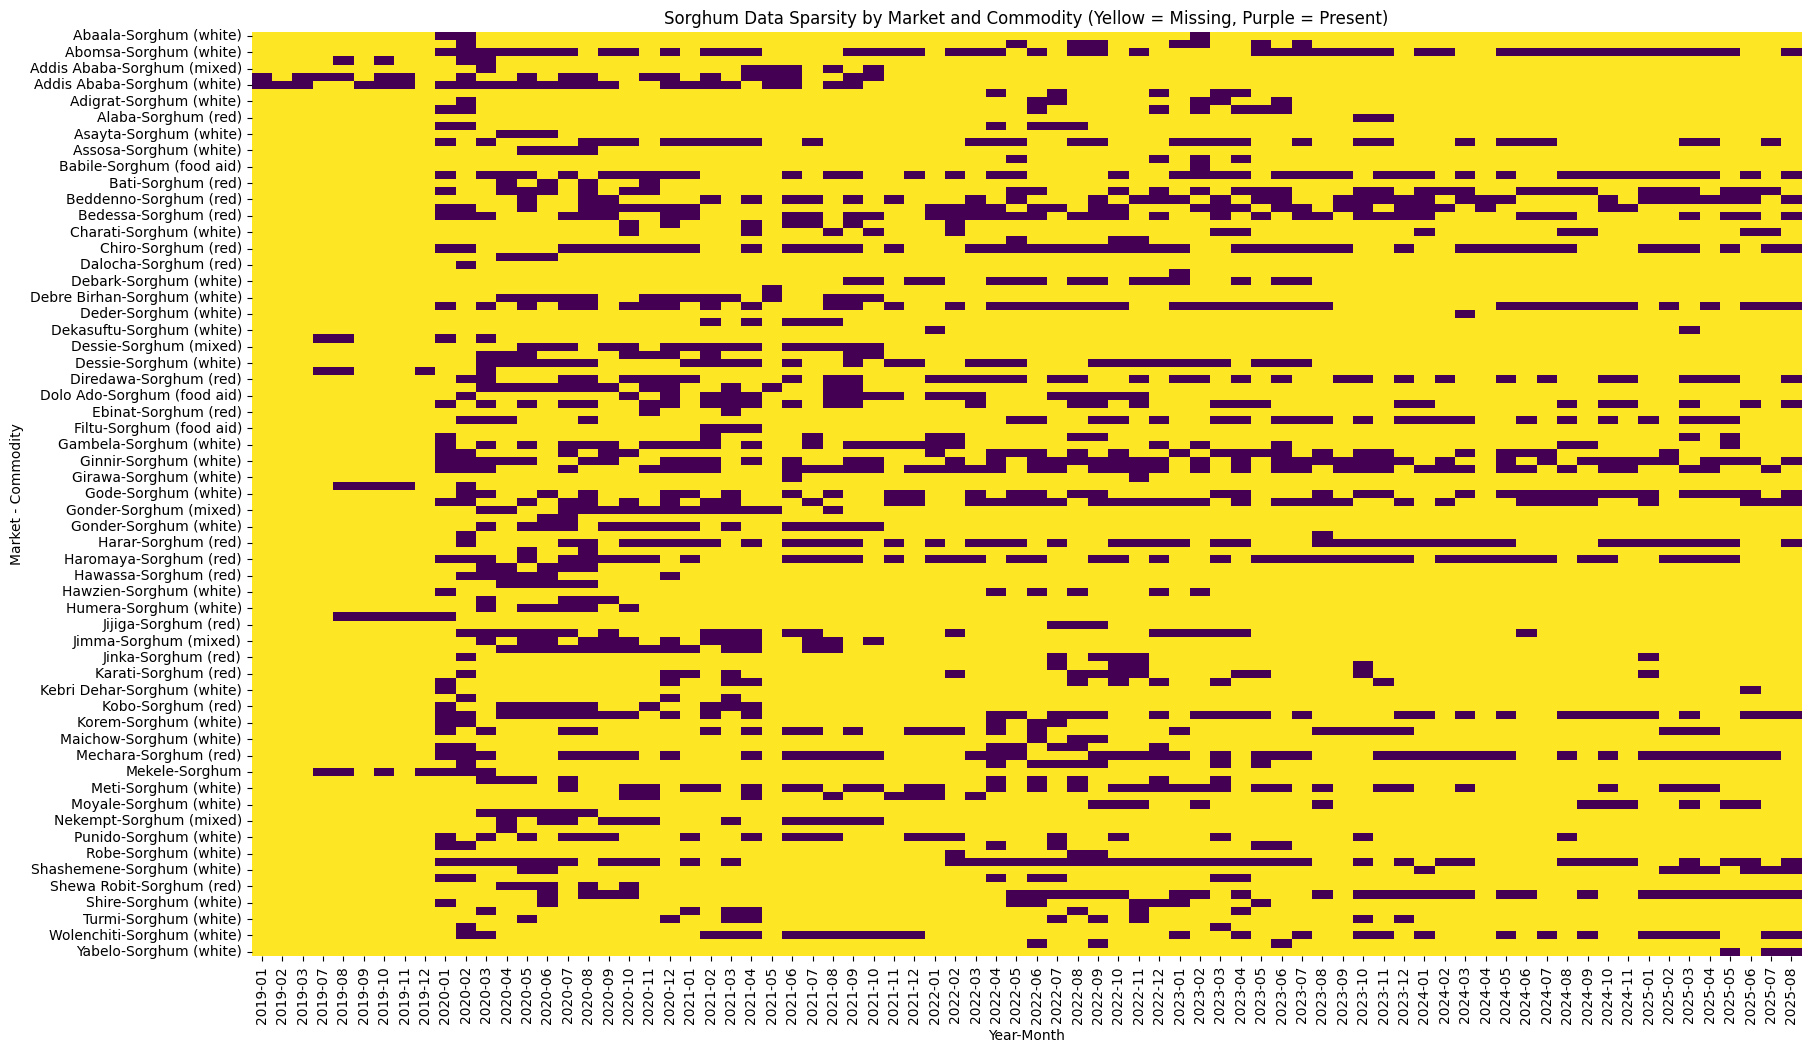

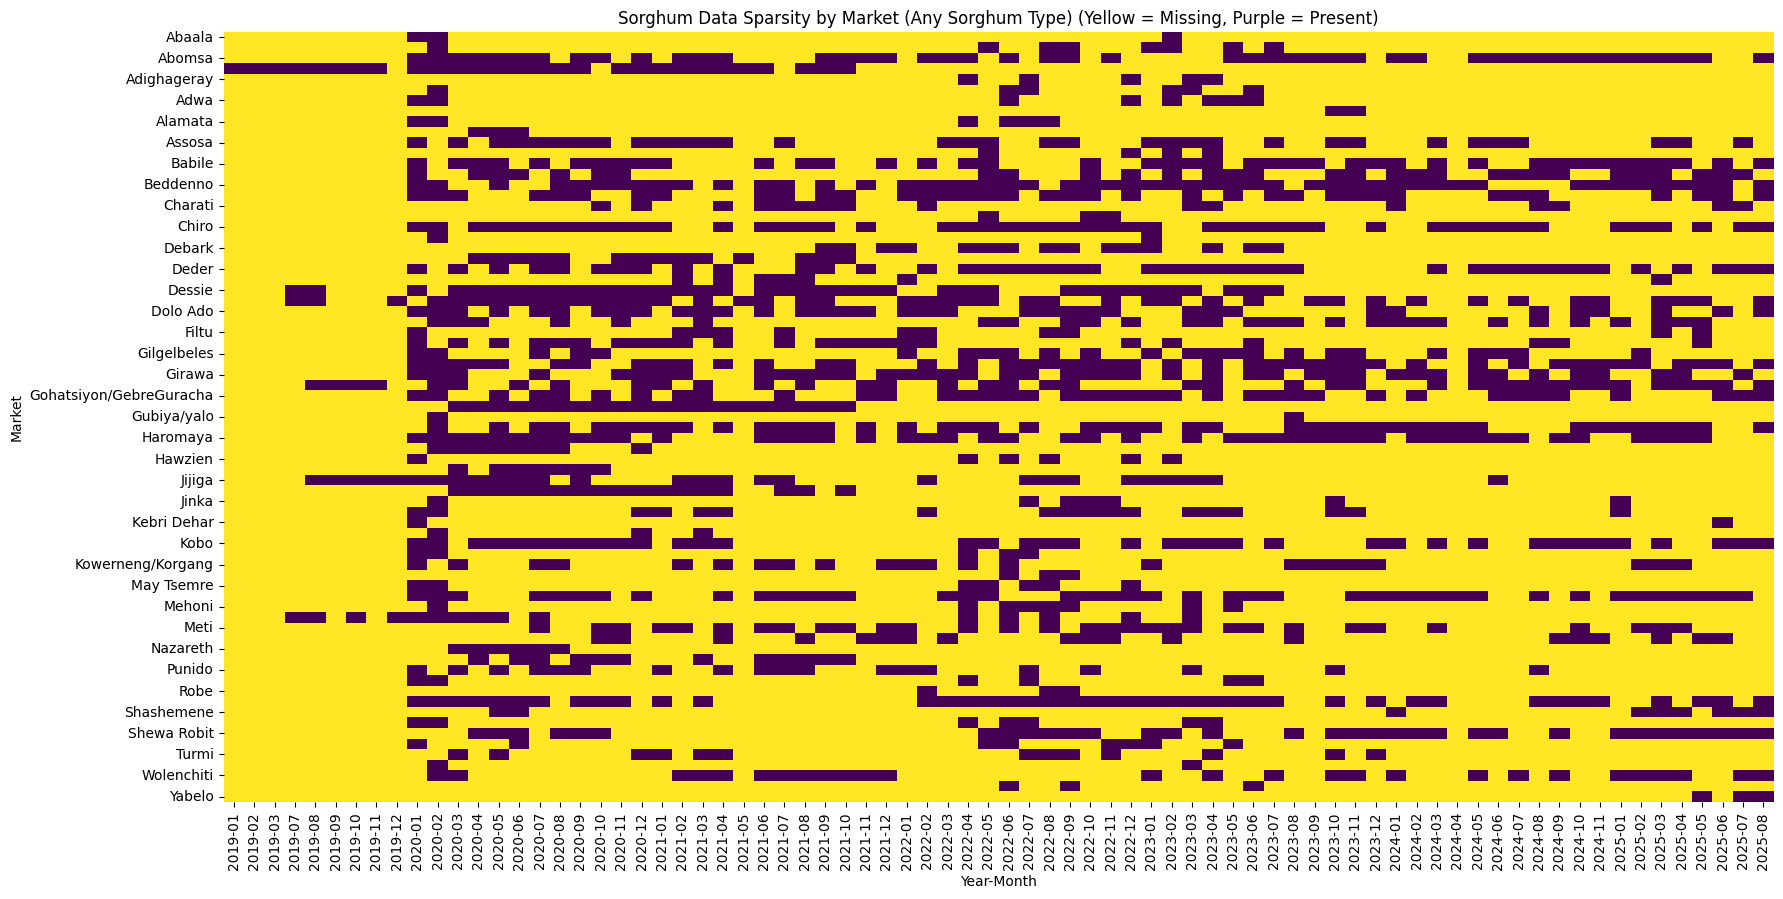

In [4]:
# Analysis of Sorghum Data Sparsity
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filter for Sorghum
# Use 'eth' dataframe if available, otherwise filter from 'df'
if 'eth' in locals():
    source_df = eth.copy()
elif 'df' in locals():
    # Ensure date is datetime if loading from raw df
    if 'date' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'])
    source_df = df[df['countryiso3']=='ETH'].copy()
else:
    print("Pre-requisite dataframes (df or eth) not found in locals. Ensure data is loaded.")
    source_df = pd.DataFrame() 

if not source_df.empty:
    # Filter for Sorghum
    target_df = source_df[source_df['commodity'].str.contains('Sorghum', case=False)].copy()
    print(f"Sorghum records found: {len(target_df)}")

    # Ensure date is datetime
    if not pd.api.types.is_datetime64_any_dtype(target_df['date']):
        target_df['date'] = pd.to_datetime(target_df['date'])
        
    target_df['ym'] = target_df['date'].dt.to_period('M')

    # 2. Visualize Sparsity
    # Pivot: Index=[Market, Commodity], Columns=Year-Month
    pivot_df = target_df.pivot_table(
        index=['market', 'commodity'], 
        columns='ym', 
        values='price', 
        aggfunc='count'
    )
    
    # Heatmap of Missing Values
    plt.figure(figsize=(20, 12))
    sns.heatmap(pivot_df.isnull(), cbar=False, cmap='viridis')
    plt.title("Sorghum Data Sparsity by Market and Commodity (Yellow = Missing, Purple = Present)")
    plt.xlabel("Year-Month")
    plt.ylabel("Market - Commodity")
    plt.show()

    # Aggregated by Market only (Market-level availability)
    pivot_market = target_df.pivot_table(
        index='market', 
        columns='ym', 
        values='price', 
        aggfunc='count'
    )
    
    plt.figure(figsize=(20, 10))
    sns.heatmap(pivot_market.isnull(), cbar=False, cmap='viridis')
    plt.title("Sorghum Data Sparsity by Market (Any Sorghum Type) (Yellow = Missing, Purple = Present)")
    plt.xlabel("Year-Month")
    plt.ylabel("Market")
    plt.show()
else:
    print("Source DataFrame is empty. Cannot analyze.")


In [5]:
import pandas as pd

wld_df = pd.read_csv("../../data/worldbank_imputed_data/WLD_RTFP_mkt_2026-01-13.csv")

In [ ]:
target_country = wld_df[wld_df['ISO3'].isin(['ETH', 'KEN', 'SOM'])]

In [11]:
target_country

,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,DATES,year,...,l_yogurt,c_yogurt,inflation_yogurt,trust_yogurt,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
218632,KEN,Kenya,Coast,Tana River,Adele Center,-0.47,39.61,gid_-4700000396100000,2007-01-01,2007,...,NaN,NaN,NaN,NaN,0.55,0.56,0.54,0.55,NaN,9.4
218633,KEN,Kenya,Coast,Tana River,Adele Center,-0.47,39.61,gid_-4700000396100000,2007-02-01,2007,...,NaN,NaN,NaN,NaN,0.55,0.57,0.54,0.57,NaN,9.4
218634,KEN,Kenya,Coast,Tana River,Adele Center,-0.47,39.61,gid_-4700000396100000,2007-03-01,2007,...,NaN,NaN,NaN,NaN,0.58,0.59,0.56,0.58,NaN,9.4
218635,KEN,Kenya,Coast,Tana River,Adele Center,-0.47,39.61,gid_-4700000396100000,2007-04-01,2007,...,NaN,NaN,NaN,NaN,0.58,0.59,0.57,0.57,NaN,9.4
218636,KEN,Kenya,Coast,Tana River,Adele Center,-0.47,39.61,gid_-4700000396100000,2007-05-01,2007,...,NaN,NaN,NaN,NaN,0.57,0.60,0.56,0.60,NaN,9.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544992,SOM,Somalia,Market Average,Market Average,Market Average,NaN,NaN,gid_som_national_average,2025-09-01,2025,...,NaN,NaN,NaN,NaN,1.59,1.62,1.55,1.58,0.07,9.9
544993,SOM,Somalia,Market Average,Market Average,Market Average,NaN,NaN,gid_som_national_average,2025-10-01,2025,...,NaN,NaN,NaN,NaN,1.59,1.62,1.56,1.59,0.64,9.9
544994,SOM,Somalia,Market Average,Market Average,Market Average,NaN,NaN,gid_som_national_average,2025-11-01,2025,...,NaN,NaN,NaN,NaN,1.60,1.63,1.57,1.60,1.97,9.9
544995,SOM,Somalia,Market Average,Market Average,Market Average,NaN,NaN,gid_som_national_average,2025-12-01,2025,...,NaN,NaN,NaN,NaN,1.61,1.64,1.58,1.60,3.51,9.9


In [19]:
list(target_country.columns.unique())

['ISO3',
 'country',
 'adm1_name',
 'adm2_name',
 'mkt_name',
 'lat',
 'lon',
 'geo_id',
 'DATES',
 'year',
 'month',
 'currency',
 'components',
 'start_dense_data',
 'last_survey_point',
 'data_coverage',
 'data_coverage_recent',
 'index_confidence_score',
 'spatially_interpolated',
 'apples',
 'bananas',
 'beans',
 'beans_egyptian',
 'beans_eyed_fao',
 'beans_fao',
 'beef_bone_in_fao',
 'bread',
 'bread_fao',
 'bulgur',
 'cabbage',
 'carrots',
 'cassava',
 'cassava_fao',
 'cassava_flour',
 'cassava_leaves',
 'cassava_meal',
 'cheese',
 'chickpeas',
 'chili',
 'cocoa',
 'cocoyam_fao',
 'coffee_instant',
 'couscous',
 'couscous_fao',
 'cowpeas',
 'cowpeas_fao',
 'cucumbers',
 'dates',
 'eggplants',
 'eggs',
 'eggs_fao',
 'fish',
 'fish_catfish',
 'fish_catfish_smoked_fao',
 'fish_goldstripe_sardinella',
 'fish_milkfish',
 'fish_mullet_catfish',
 'fish_roundscad',
 'fish_sardine_canned',
 'fish_smoked',
 'fish_tilapia',
 'fish_tilapia_fao',
 'fish_tuna_canned',
 'fish_various',
 'fonio